# Final Visualisations and Results Summary

This notebook brings together the main findings from the exploratory analysis and forecasting stages of the project.

The purpose is to create a concise collection of publication-quality figures and summary tables that can be used in the dissertation results and discussion chapters. The notebook includes national EV growth, technology and keepership comparisons, regional adoption patterns, population-adjusted registration rates and ARIMA forecasting performance.

## Import Required Libraries

The following libraries are used to load the processed datasets, prepare summary tables and create the final visualisations.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Define Project Folders

The processed datasets, exported forecasting results, final figures and dissertation tables are stored in separate project folders.

In [2]:
# Define the main project folders

project_folder = Path.cwd().parent

processed_folder = project_folder / "Datasets" / "processed"
figures_folder = project_folder / "Figures"
tables_folder = project_folder / "Tables"

# Create output folders if they do not already exist

figures_folder.mkdir(parents=True, exist_ok=True)
tables_folder.mkdir(parents=True, exist_ok=True)

print("Project folder :", project_folder)
print("Processed data :", processed_folder)
print("Figures folder :", figures_folder)
print("Tables folder  :", tables_folder)

Project folder : /Users/adityakumar/Desktop/EV_Dissertation
Processed data : /Users/adityakumar/Desktop/EV_Dissertation/Datasets/processed
Figures folder : /Users/adityakumar/Desktop/EV_Dissertation/Figures
Tables folder  : /Users/adityakumar/Desktop/EV_Dissertation/Tables


## Load Processed Data and Forecasting Results

The cleaned EV registration data, integrated regional dataset, charging infrastructure data and ARIMA forecast results are loaded for the final visualisation stage.

In [3]:
# Load processed datasets

ev_uk = pd.read_csv(
    processed_folder / "ev_clean.csv",
    low_memory=False
)

ev_regional = pd.read_csv(
    processed_folder / "ev_integrated.csv",
    low_memory=False
)

charging_data = pd.read_csv(
    processed_folder / "charging_clean.csv",
    low_memory=False
)

forecast_results = pd.read_csv(
    tables_folder / "arima_forecast_results.csv"
)

print("UK EV dataset          :", ev_uk.shape)
print("Regional EV dataset    :", ev_regional.shape)
print("Charging dataset       :", charging_data.shape)
print("Forecast results       :", forecast_results.shape)

UK EV dataset          : (285505, 62)
Regional EV dataset    : (247667, 66)
Charging dataset       : (433, 29)
Forecast results       : (8, 4)


In [4]:
# Preview the forecast results

forecast_results.head()

,Date,Quarter,EV_Registrations,Forecast
0,2024-04-01,2024 Q2,"1,799,851.00","1,802,515.58"
1,2024-07-01,2024 Q3,"1,949,503.00","1,925,859.16"
2,2024-10-01,2024 Q4,"2,090,088.00","2,049,202.74"
3,2025-01-01,2025 Q1,"2,265,036.00","2,172,546.32"
4,2025-04-01,2025 Q2,"2,427,221.00","2,295,889.90"


## National Growth of UK EV Registrations

The figure below illustrates the long-term increase in UK electric vehicle registrations from 2011 to 2026. This visual summarises the national adoption trend observed throughout the study.

In [5]:
# Select published total records only

national_total_rows = ev_uk[
    (ev_uk["Fuel"] == "Total") &
    (ev_uk["Keepership"] == "Total")
].copy()

# Identify quarterly columns

quarter_cols = [
    column for column in national_total_rows.columns
    if "Q" in column and column[:4].isdigit()
]

# Sort quarters chronologically

quarter_cols = sorted(
    quarter_cols,
    key=lambda x: (
        int(x.split()[0]),
        int(x.split()[1][1])
    )
)

# Sum all LSOAs to obtain national quarterly totals

national_series = (
    national_total_rows[quarter_cols]
    .sum(axis=0, min_count=1)
    .reset_index()
)

national_series.columns = [
    "Quarter",
    "EV_Registrations"
]

# Convert quarter labels to dates

quarter_months = {
    "Q1": 1,
    "Q2": 4,
    "Q3": 7,
    "Q4": 10
}

national_series["Date"] = national_series["Quarter"].apply(
    lambda value: pd.Timestamp(
        year=int(value.split()[0]),
        month=quarter_months[value.split()[1]],
        day=1
    )
)

national_series.head()

,Quarter,EV_Registrations,Date
0,2011 Q4,"4,657.00",2011-10-01
1,2012 Q1,"4,935.00",2012-01-01
2,2012 Q2,"5,335.00",2012-04-01
3,2012 Q3,"5,363.00",2012-07-01
4,2012 Q4,"5,852.00",2012-10-01


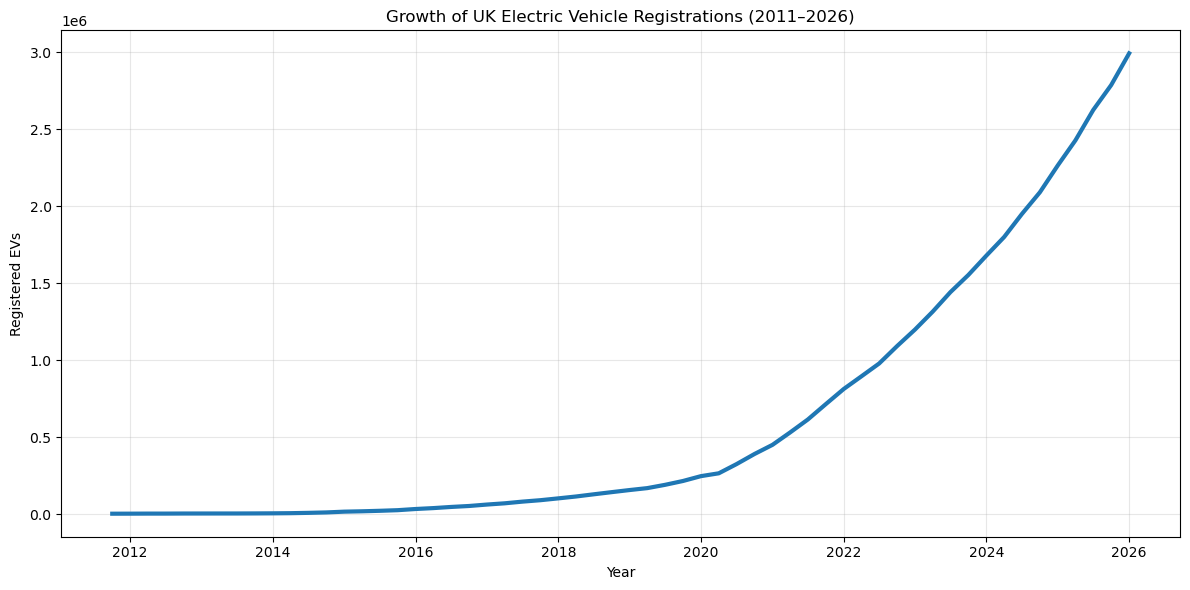

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    national_series["Date"],
    national_series["EV_Registrations"],
    linewidth=3
)

plt.title("Growth of UK Electric Vehicle Registrations (2011–2026)")
plt.xlabel("Year")
plt.ylabel("Registered EVs")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_01_UK_EV_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top 20 Local Authorities by EV Registrations

The figure below presents the twenty local authorities with the highest number of registered electric vehicles in the first quarter of 2026. This comparison highlights geographical differences in EV adoption across England and Wales.

In [7]:
# Top 20 Local Authorities by EV registrations

top_lad = (
    ev_regional[
        (ev_regional["Fuel"] == "Total") &
        (ev_regional["Keepership"] == "Total")
    ]
    .groupby("lad_name")["2026 Q1"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_lad

lad_name
Windsor and Maidenhead      240,399.00
Milton Keynes               136,325.00
Stockport                   119,920.00
Peterborough                104,309.00
Leeds                        89,449.00
Cheshire West and Chester    71,285.00
South Gloucestershire        64,038.00
Wiltshire                    53,547.00
Westminster                  52,547.00
Slough                       51,013.00
Buckinghamshire              24,634.00
Portsmouth                   24,486.00
North Yorkshire              23,350.00
Solihull                     21,527.00
Birmingham                   19,100.00
Cheshire East                18,205.00
North Northamptonshire       16,765.00
Hillingdon                   15,582.00
Rushmoor                     15,308.00
Somerset                     15,070.00
Name: 2026 Q1, dtype: float64

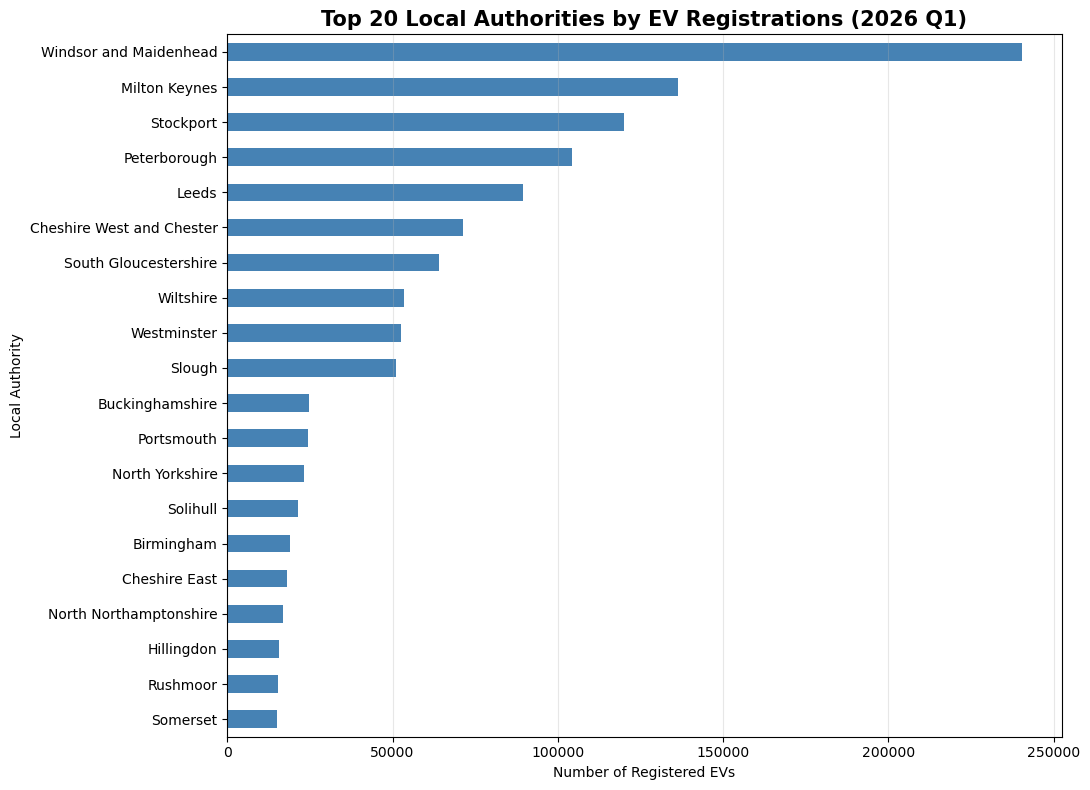

In [8]:
plt.figure(figsize=(11,8))

top_lad.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title(
    "Top 20 Local Authorities by EV Registrations (2026 Q1)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Registered EVs")
plt.ylabel("Local Authority")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_02_Top_Local_Authorities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 3: ARIMA Forecast versus Actual EV Registrations

This figure compares the observed EV registrations with the values predicted by the ARIMA model during the testing period. It provides a visual assessment of the forecasting accuracy.

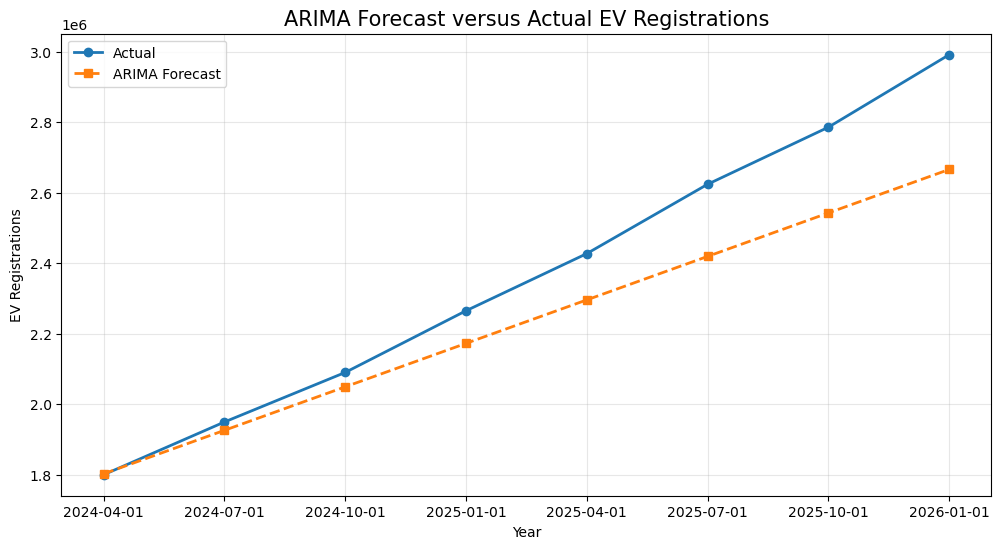

In [9]:
plt.figure(figsize=(12,6))

# Actual values
plt.plot(
    forecast_results["Date"],
    forecast_results["EV_Registrations"],
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast values
plt.plot(
    forecast_results["Date"],
    forecast_results["Forecast"],
    linestyle="--",
    marker="s",
    linewidth=2,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast versus Actual EV Registrations", fontsize=15)
plt.xlabel("Year")
plt.ylabel("EV Registrations")

plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    figures_folder / "Figure_03_ARIMA_Forecast_vs_Actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 4: EV Registrations per 100,000 Population

This figure ranks the leading local authorities after adjusting EV registrations by population size. Normalising the data allows fairer comparison between large and small local authorities.

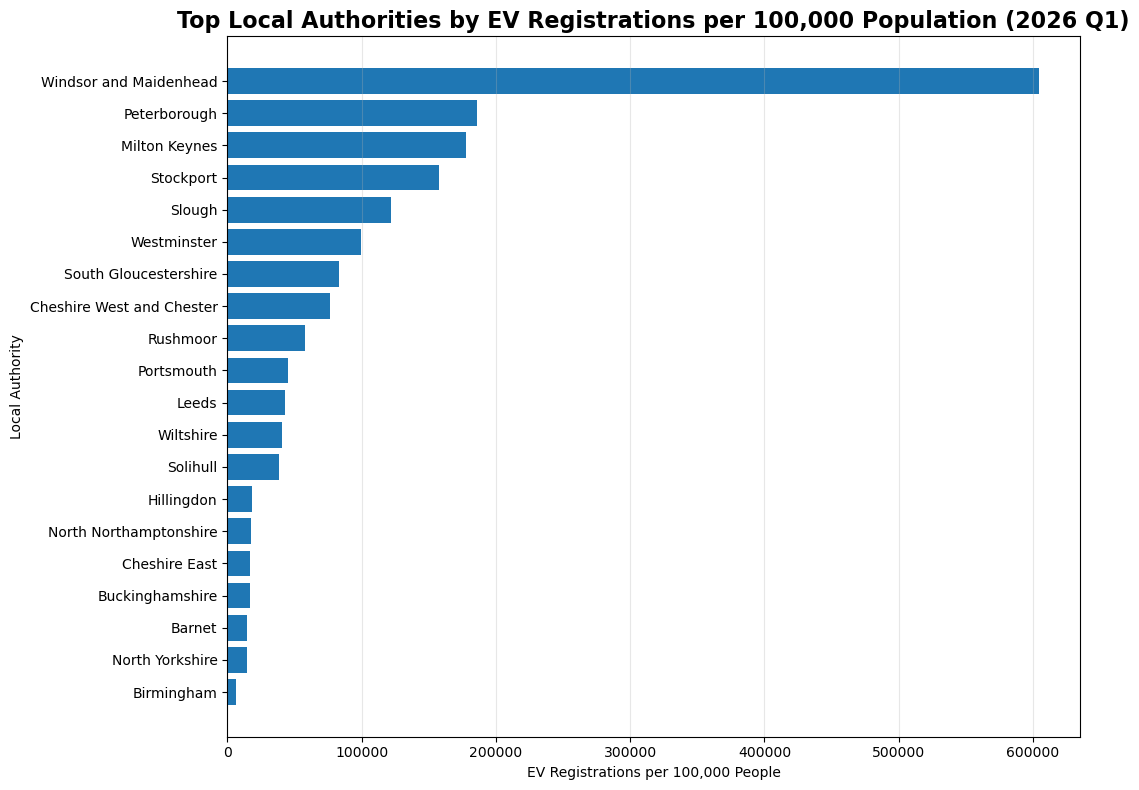

In [10]:
# Create Top 20 Local Authorities
top20 = (
    ev_regional
    .groupby("lad_name")["2026 Q1"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

# Calculate population for each Local Authority
population_la = (
    ev_regional[
        ["lsoa_code", "lad_name", "population_2024"]
    ]
    .drop_duplicates(subset="lsoa_code")
    .groupby("lad_name")["population_2024"]
    .sum()
)

# Merge population
top20["Population"] = top20["lad_name"].map(population_la)

# EV registrations per 100,000 population
top20["EV_per_100k"] = (
    top20["2026 Q1"] / top20["Population"]
) * 100000

# Sort by density
top20 = top20.sort_values(
    "EV_per_100k",
    ascending=False
)

# Plot
plt.figure(figsize=(11, 8))

plt.barh(
    top20["lad_name"],
    top20["EV_per_100k"]
)

plt.title(
    "Top Local Authorities by EV Registrations per 100,000 Population (2026 Q1)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("EV Registrations per 100,000 People")
plt.ylabel("Local Authority")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_04_EV_per_100k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 5: Growth of Public Charging Infrastructure

This figure shows the increase in publicly available electric vehicle charging devices across the United Kingdom between October 2019 and April 2026. It provides an overview of how charging infrastructure expanded alongside rising EV adoption.

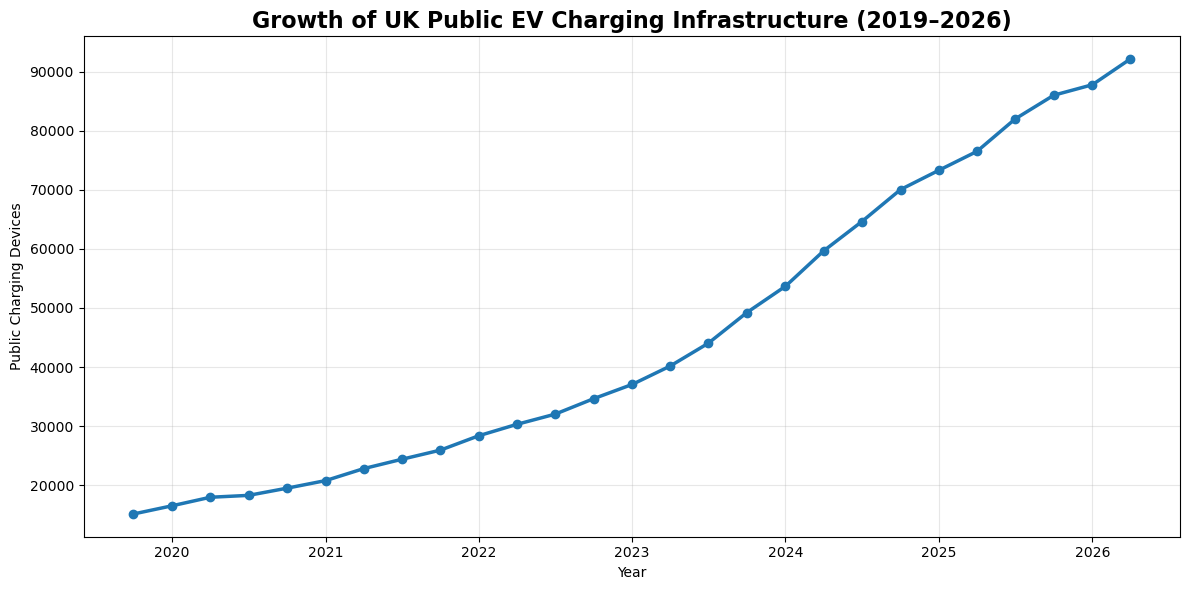

In [11]:
# Select the United Kingdom total
uk_charging = charging_data[
    charging_data["area_name"] == "United Kingdom"
].copy()

# Check that exactly one UK row is available
if len(uk_charging) != 1:
    raise ValueError(
        f"Expected one United Kingdom row, but found {len(uk_charging)}."
    )

# Identify the date columns
charging_date_columns = [
    column
    for column in charging_data.columns
    if column not in ["area_code", "area_name"]
]

# Convert the national row into long format
charging_series = (
    uk_charging[charging_date_columns]
    .iloc[0]
    .reset_index()
)

charging_series.columns = [
    "Period",
    "Charging_Devices"
]

# Convert period labels such as Oct-19 into dates
charging_series["Date"] = pd.to_datetime(
    charging_series["Period"],
    format="%b-%y"
)

charging_series["Charging_Devices"] = pd.to_numeric(
    charging_series["Charging_Devices"],
    errors="coerce"
)

charging_series = charging_series.dropna(
    subset=["Date", "Charging_Devices"]
).sort_values("Date")

# Create the figure
plt.figure(figsize=(12, 6))

plt.plot(
    charging_series["Date"],
    charging_series["Charging_Devices"],
    marker="o",
    linewidth=2.5
)

plt.title(
    "Growth of UK Public EV Charging Infrastructure (2019–2026)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Public Charging Devices")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_05_UK_Charging_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 6: EV Registrations by Fuel Type

This figure compares the main electric vehicle technologies recorded in the first quarter of 2026. The total category is excluded to avoid double-counting, while total keepership records are used to ensure that each vehicle is counted once.

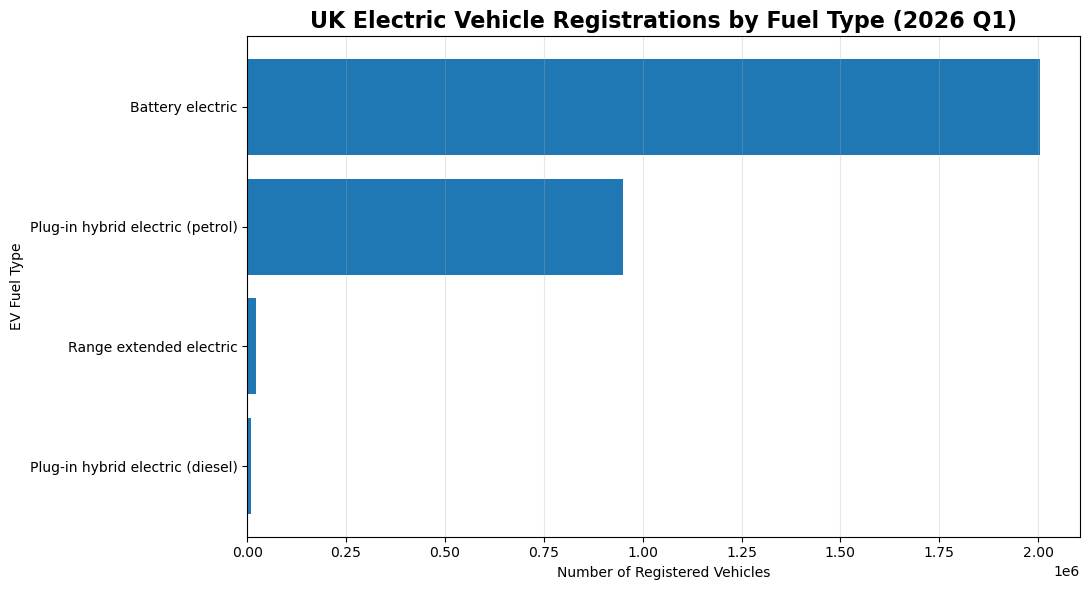

Fuel
Battery electric                   2,005,433.00
Plug-in hybrid electric (petrol)     949,804.00
Range extended electric               21,317.00
Plug-in hybrid electric (diesel)      10,457.00
Name: 2026 Q1, dtype: float64

In [12]:
# Select total keepership records and exclude the overall total
fuel_distribution = (
    ev_uk[
        (ev_uk["Keepership"] == "Total") &
        (ev_uk["Fuel"] != "Total")
    ]
    .groupby("Fuel")["2026 Q1"]
    .sum()
    .sort_values(ascending=True)
)

# Create the plot
plt.figure(figsize=(11, 6))

plt.barh(
    fuel_distribution.index,
    fuel_distribution.values
)

plt.title(
    "UK Electric Vehicle Registrations by Fuel Type (2026 Q1)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Registered Vehicles")
plt.ylabel("EV Fuel Type")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_06_EV_Fuel_Type_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display the values used in the figure
fuel_distribution.sort_values(ascending=False)

## Figure 7: Correlation between Key EV Adoption Indicators

This figure presents the correlation between the key variables used in this study, including electric vehicle registrations, local population, and EV registrations per 100,000 population.

In [13]:
correlation_data = (
    ev_regional[
        [
            "lad_name",
            "2026 Q1",
            "population_2024"
        ]
    ]
    .drop_duplicates(subset="lad_name")
    .copy()
)

correlation_data["EV_per_100k"] = (
    correlation_data["2026 Q1"]
    / correlation_data["population_2024"]
) * 100000

correlation_data.head()

,lad_name,2026 Q1,population_2024,EV_per_100k
0,City of London,13.00,2172,598.53
3,Barking and Dagenham,7.00,3080,227.27
68,Barnet,10.00,1381,724.11
245,Bexley,6.00,1683,356.51
313,Brent,19.00,2810,676.16


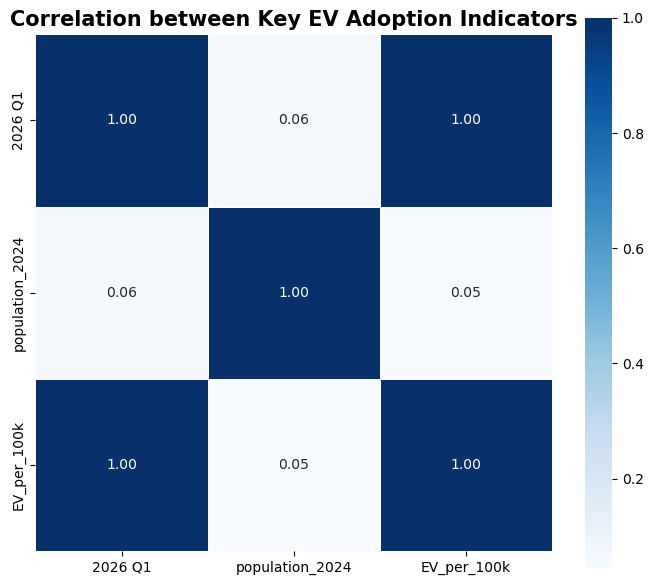

,2026 Q1,population_2024,EV_per_100k
2026 Q1,1.00,0.06,1.00
population_2024,0.06,1.00,0.05
EV_per_100k,1.00,0.05,1.00


In [14]:
import seaborn as sns

corr_matrix = correlation_data[
    [
        "2026 Q1",
        "population_2024",
        "EV_per_100k"
    ]
].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation between Key EV Adoption Indicators",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_07_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

corr_matrix

## Figure 8: Top 20 Local Authorities by Public EV Charging Devices (April 2026)

This visualisation identifies the twenty local authorities with the highest number of public electric vehicle (EV) charging devices in April 2026. National totals, regional summaries, and other aggregated geographical categories were excluded to ensure that only local authority-level data were compared.

The figure highlights the uneven distribution of charging infrastructure across the UK and identifies the areas with the most developed public charging networks. These results provide insight into regional differences in charging infrastructure availability and support the analysis of how charging provision relates to EV adoption across different local authorities.

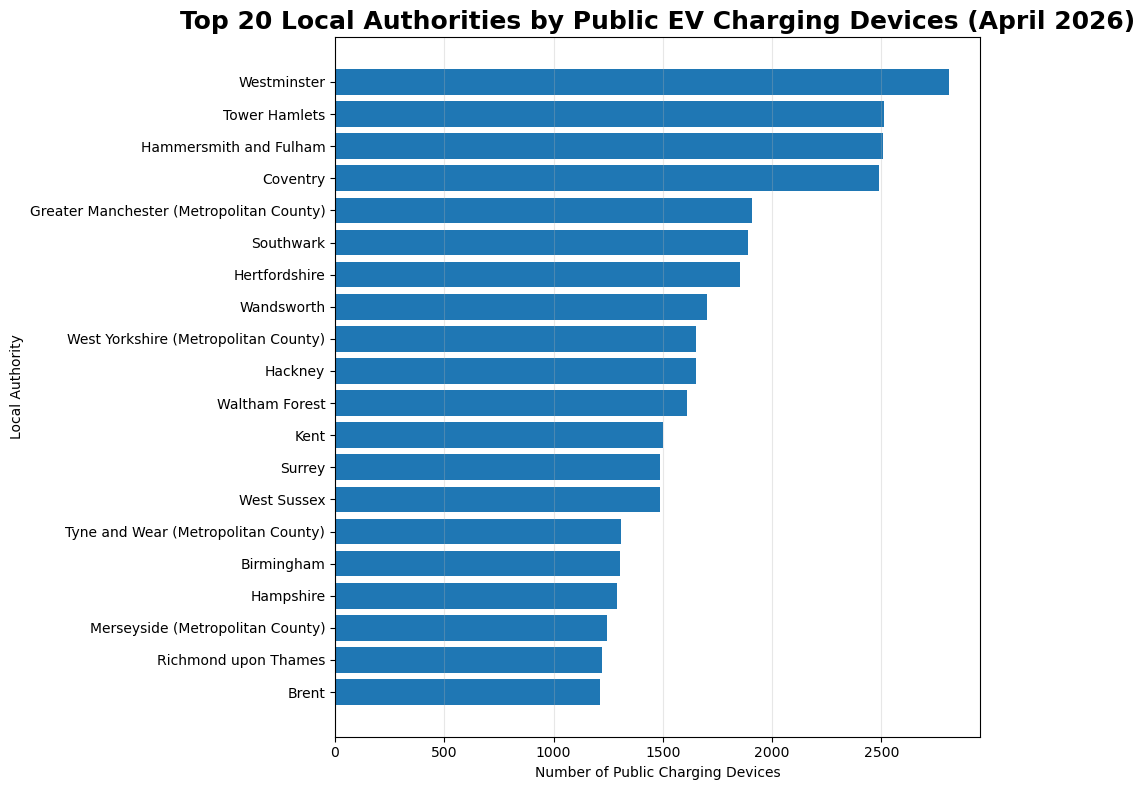

,area_name,Apr-26
238,Westminster,"2,811.00"
236,Tower Hamlets,"2,510.00"
228,Hammersmith and Fulham,"2,506.00"
159,Coventry,"2,490.00"
33,Greater Manchester (Metropolitan County),"1,910.00"
235,Southwark,"1,890.00"
198,Hertfordshire,"1,855.00"
237,Wandsworth,"1,702.00"
83,West Yorkshire (Metropolitan County),"1,654.00"
227,Hackney,"1,653.00"


In [15]:
exclude = [
    "United Kingdom",
    "Great Britain",
    "England",
    "Northern Ireland",
    "Scotland",
    "Wales",
    "North East",
    "North West",
    "Yorkshire and the Humber",
    "East Midlands",
    "West Midlands",
    "East of England",
    "London",
    "Inner London",
    "Outer London",
    "South East",
    "South West",
    "West Midlands (Metropolitan County)"
]

charging_la = charging_data[
    ~charging_data["area_name"].isin(exclude)
].copy()

top20_chargers = (
    charging_la[["area_name", "Apr-26"]]
    .sort_values("Apr-26", ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top20_chargers["area_name"][::-1],
    top20_chargers["Apr-26"][::-1]
)

plt.title(
    "Top 20 Local Authorities by Public EV Charging Devices (April 2026)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Number of Public Charging Devices")
plt.ylabel("Local Authority")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_08_Top20_Charging_LocalAuthorities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

top20_chargers

## Figure 9: Local Authorities with the Largest Annual Increase in EV Registrations

This figure identifies the twenty local authorities that recorded the largest absolute increase in electric vehicle registrations between the first quarter of 2025 and the first quarter of 2026. The analysis uses published total vehicle and total keepership records to avoid double-counting.

The comparison highlights where EV registrations expanded most strongly during the latest twelve-month period available in the dataset.

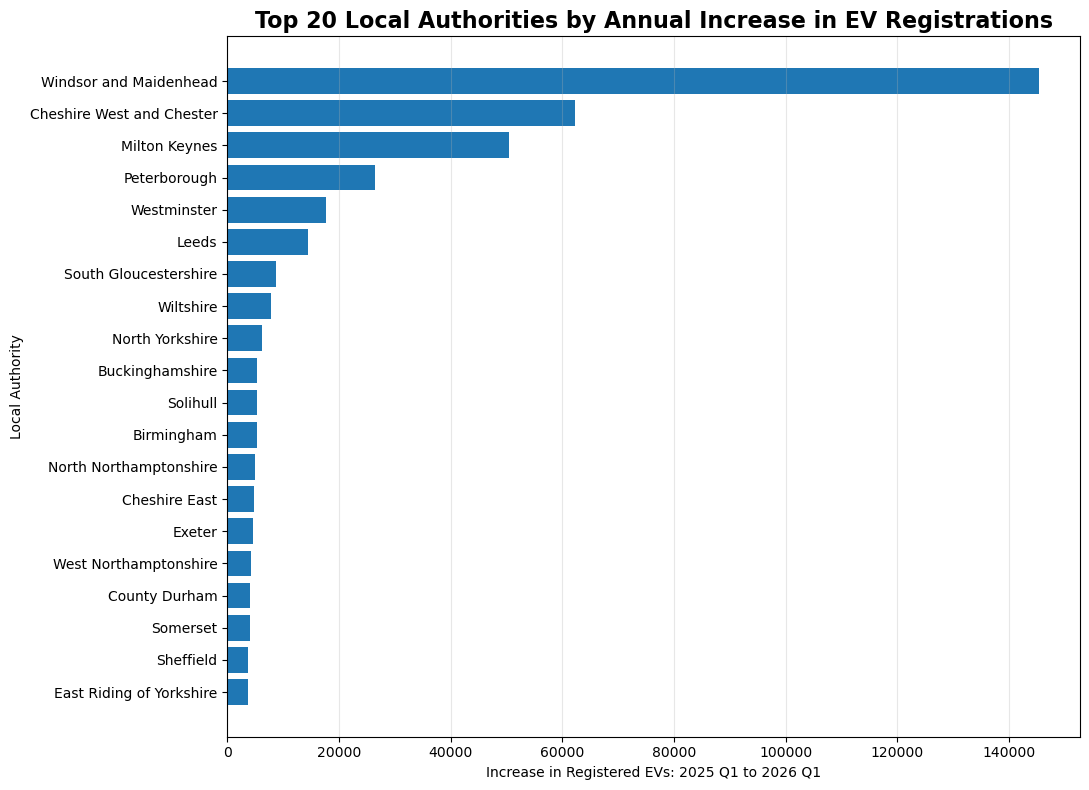

,lad_name,2025 Q1,2026 Q1,Annual_Increase
306,Windsor and Maidenhead,"94,988.00","240,399.00","145,411.00"
57,Cheshire West and Chester,"9,102.00","71,285.00","62,183.00"
168,Milton Keynes,"85,851.00","136,325.00","50,474.00"
200,Peterborough,"77,804.00","104,309.00","26,505.00"
301,Westminster,"34,932.00","52,547.00","17,615.00"
147,Leeds,"74,916.00","89,449.00","14,533.00"
234,South Gloucestershire,"55,299.00","64,038.00","8,739.00"
304,Wiltshire,"45,769.00","53,547.00","7,778.00"
190,North Yorkshire,"17,175.00","23,350.00","6,175.00"
38,Buckinghamshire,"19,224.00","24,634.00","5,410.00"


In [16]:
# Select published total records only
annual_growth_data = ev_regional[
    (ev_regional["Fuel"] == "Total") &
    (ev_regional["Keepership"] == "Total")
].copy()

# Aggregate registrations to Local Authority level
annual_growth_lad = (
    annual_growth_data
    .groupby("lad_name", as_index=False)[["2025 Q1", "2026 Q1"]]
    .sum(min_count=1)
)

# Calculate the absolute increase over twelve months
annual_growth_lad["Annual_Increase"] = (
    annual_growth_lad["2026 Q1"] -
    annual_growth_lad["2025 Q1"]
)

# Keep the 20 Local Authorities with the largest increase
top20_annual_growth = (
    annual_growth_lad
    .dropna(subset=["Annual_Increase"])
    .sort_values("Annual_Increase", ascending=False)
    .head(20)
)

# Create the figure
plt.figure(figsize=(11, 8))

plt.barh(
    top20_annual_growth["lad_name"][::-1],
    top20_annual_growth["Annual_Increase"][::-1]
)

plt.title(
    "Top 20 Local Authorities by Annual Increase in EV Registrations",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Increase in Registered EVs: 2025 Q1 to 2026 Q1")
plt.ylabel("Local Authority")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

# Save the figure
plt.savefig(
    figures_folder / "Figure_09_Annual_EV_Growth_Local_Authorities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display the values used in the figure
top20_annual_growth

## Figure 10: Distribution of Public EV Charging Devices Across UK Regions

This figure presents the distribution of public electric vehicle charging devices across major UK regions in April 2026. It highlights geographical differences in charging infrastructure and identifies the areas with the highest concentration of public charging facilities.

The figure complements the EV registration analysis by illustrating how charging infrastructure varies across the United Kingdom.

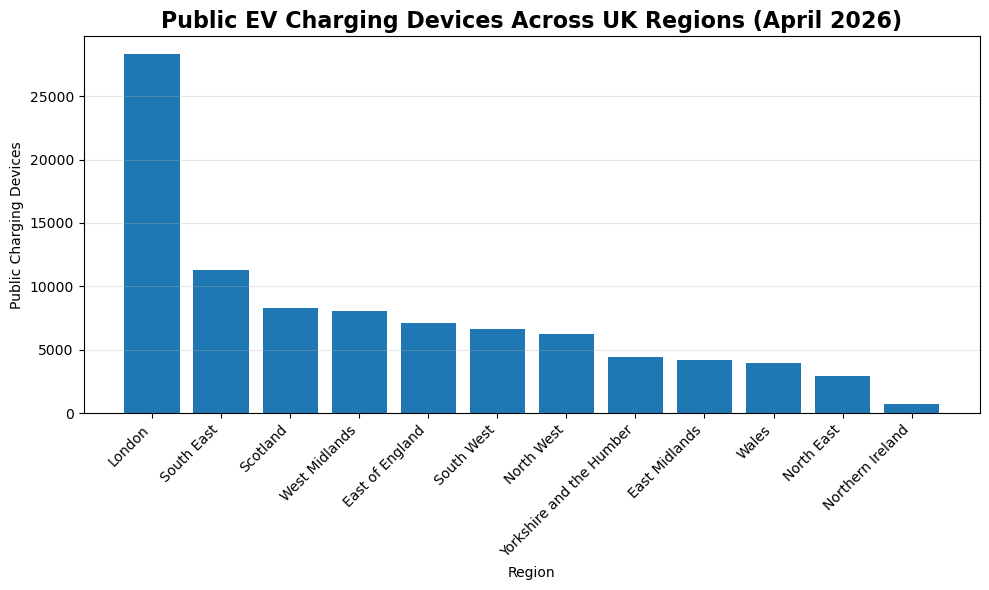

,area_name,Apr-26
223,London,"28,301.00"
259,South East,"11,308.00"
388,Scotland,"8,272.00"
137,West Midlands,"8,027.00"
172,East of England,"7,088.00"
330,South West,"6,661.00"
17,North West,"6,220.00"
63,Yorkshire and the Humber,"4,444.00"
89,East Midlands,"4,199.00"
365,Wales,"3,944.00"


In [17]:
uk_regions = [
    "North East",
    "North West",
    "Yorkshire and the Humber",
    "East Midlands",
    "West Midlands",
    "East of England",
    "London",
    "South East",
    "South West",
    "Scotland",
    "Wales",
    "Northern Ireland"
]

region_chargers = (
    charging_data[
        charging_data["area_name"].isin(uk_regions)
    ][["area_name", "Apr-26"]]
    .sort_values("Apr-26", ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    region_chargers["area_name"],
    region_chargers["Apr-26"]
)

plt.xticks(rotation=45, ha="right")

plt.title(
    "Public EV Charging Devices Across UK Regions (April 2026)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Region")
plt.ylabel("Public Charging Devices")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_10_Regional_Charging_Infrastructure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

region_chargers